# mechanism_viewer real-world examples

## Pima Indians Diabetes dataset

This notebook evaluates the package’s practicability in real‑world scenarios by applying it to an external dataset. The dataset used in this example originates from the National Institute of Diabetes and Digestive and Kidney Diseases, and its primary objective is to predict the onset of diabetes based on various diagnostic measurements.

To support this analysis, the goal of `mechanism_viewer` is to examine whether the missing values are consistent with `MCAR`, `MAR`, `MNAR`, or a mixed missingness pattern.

>Note: `mechanism_viewer` is an exploratory package, and interpretations of its results should always be made with caution.

### 1. Load and explore the dataset

In [ ]:
import pandas as pd

df = pd.read_csv("../sample_data/diabetes/diabetes.csv")
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


The distribution of each feature can be visualized with the following code:

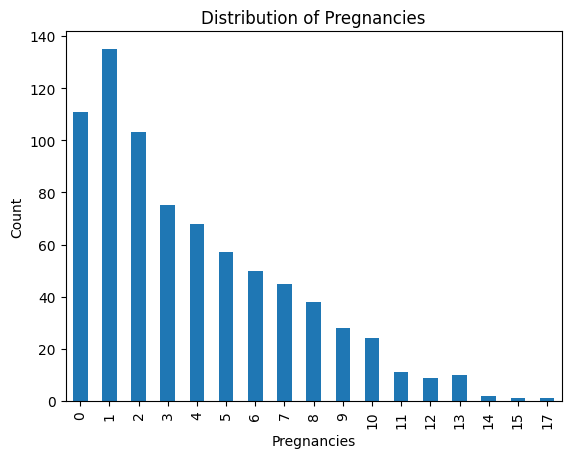

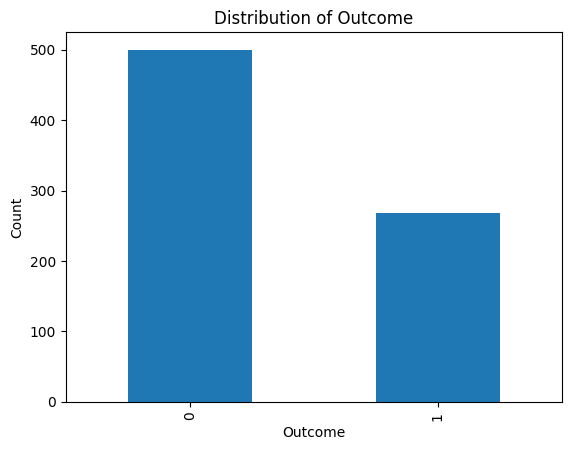

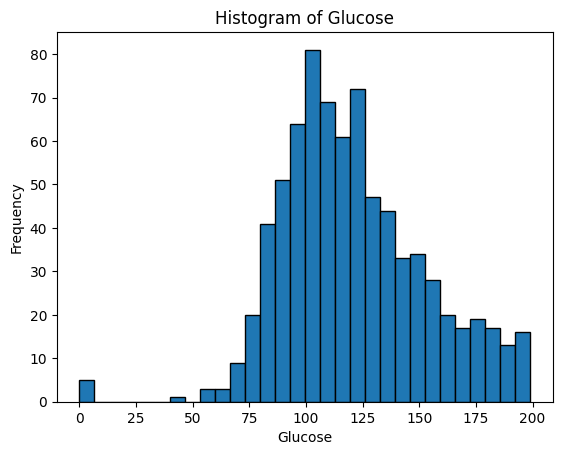

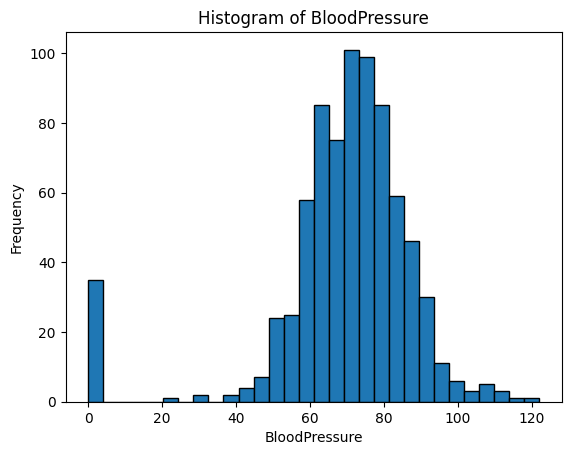

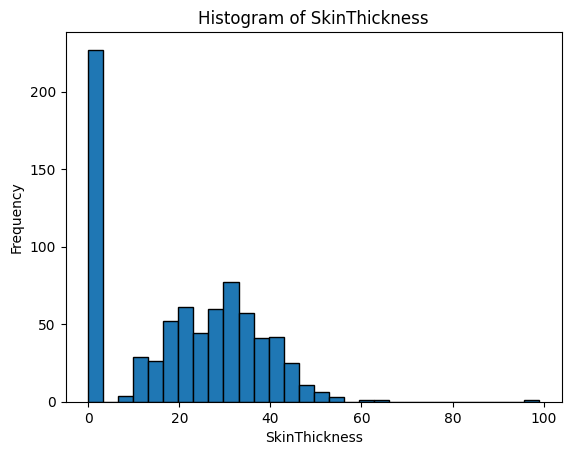

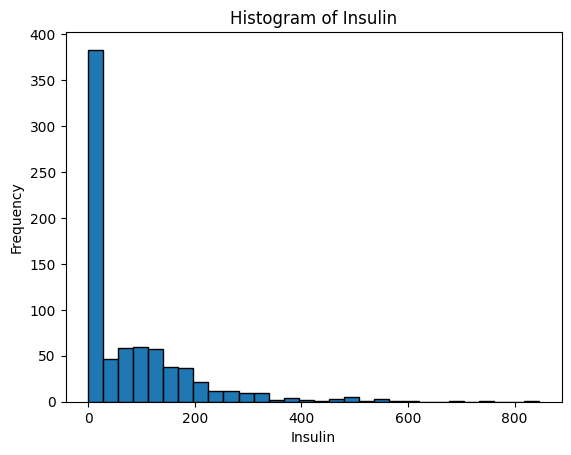

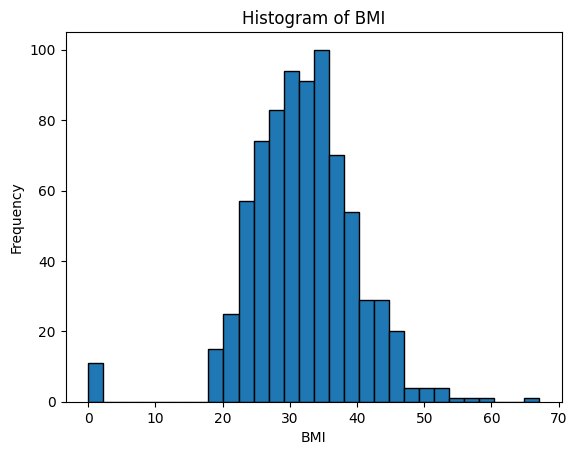

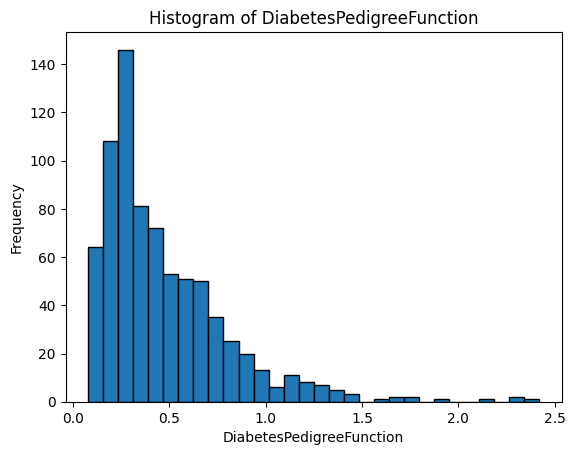

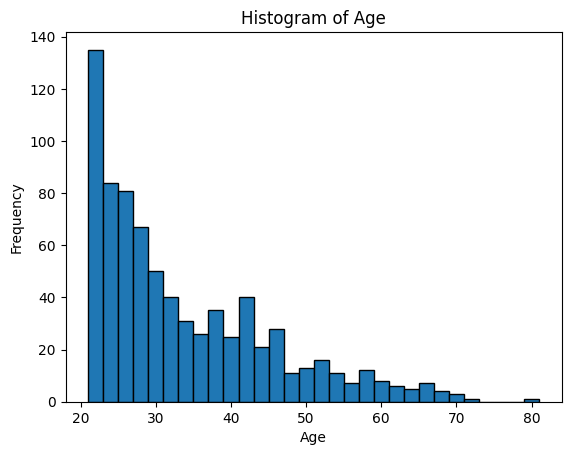

In [3]:
import matplotlib.pyplot as plt

discrete_columns = ["Pregnancies", "Outcome"]
continuous_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

for discrete_column in discrete_columns:
    df[discrete_column].value_counts().sort_index().plot(kind="bar", title=f"Distribution of {discrete_column}")
    plt.xlabel(discrete_column)
    plt.ylabel("Count")
    plt.show()

for continuous_column in continuous_columns:
    plt.hist(df[continuous_column], bins=30, edgecolor='black')
    plt.title(f"Histogram of {continuous_column}")
    plt.xlabel(continuous_column)
    plt.ylabel("Frequency")
    plt.show()

From the observed plots, it is evident that several columns contain missing values. Specifically `BMI`, `Insulin`, `SkinThickness`, `BloodPressure`, and `Glucose`. In this dataset, the value 0 appears to be in place of missing entries for these features, since a value of 0 is physiologically impossible for these measurements.

The most likely explanation is that clinicians did not record certain measurements during consultations. Thus, when the dataset was later compiled, they could not leave fields empty, so they entered 0 instead.

Of course, this notebook keeps 0 as a valid value for `Pregnancies` and `Outcome`, since in these variables a value of 0 is meaningful and does not represent missing data.

### 2. Replacing 0 values with missing-value indicators

Before using `mechanism_viewer`, the 0 values in `BMI`, `Insulin`, `SkinThickness`, `BloodPressure`, and `Glucose` will be replaced with proper missing-value indicators.

In [6]:
import numpy as np

columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[columns] = df[columns].replace(0, np.nan)

### 3. Overall missing-rate plot

The function `plot_missing_rate()` gives a quick visual overview of how much missing data exists in each column.

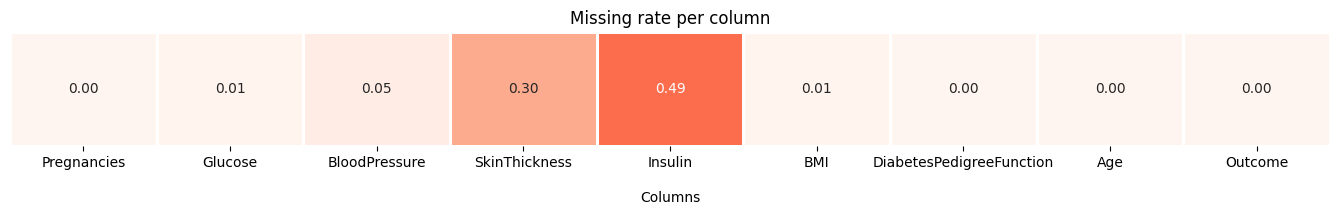

In [9]:
import mechanism_viewer as mv

_, _ = mv.plot_missing_rate(df, display_plot=True)

After transforming the missing values, it becomes clear that Insulin and SkinThickness have the highest missing rates, while BloodPressure, Glucose, and BMI show only minimal missingness. In contrast, DiabetesPedigreeFunction, Age, and Outcome remain fully observed.

It is important to note that the difference of missing rates matters. Columns with high missingness give more information for pattern detection, while columns with very low missing rate can be harder to interpret reliably.

### 4. Global MCAR test

Since there is no prior information about which variables follow which missing‑data mechanism, the analysis begins with a global assessment to determine whether the dataset as a whole is consistent with MCAR or whether a hidden missingness pattern is present. This assessment can be provided by the global Little’s MCAR test, `little_mcar_test()`.

> Note: This test does not prove MAR or MNAR. It only tells us whether the whole missingness pattern looks inconsistent with MCAR.

In [10]:
p_value = mv.little_mcar_test(df)
print(mv.interpret_mcar_p_value(p_value))


Obtained p_value is 0.0.

Interpretation: Reject the null hypothesis. Data is not MCAR (likely MAR or MNAR)


Performing the chi‑square test on the entire dataset leaded to a rejection of the null hypothesis. When this occurs, it typically indicates that at least one variable does not follow an MCAR mechanism and is instead likely to have MAR or MNAR.

The next step is to inspect which columns contribute most to that signal.

### 5. Pairwise MCAR checks

The pairwise MCAR test gives a more local view by comparing missingness patterns between pairs of columns. This helps identify which incomplete columns deserve more detailed investigation.

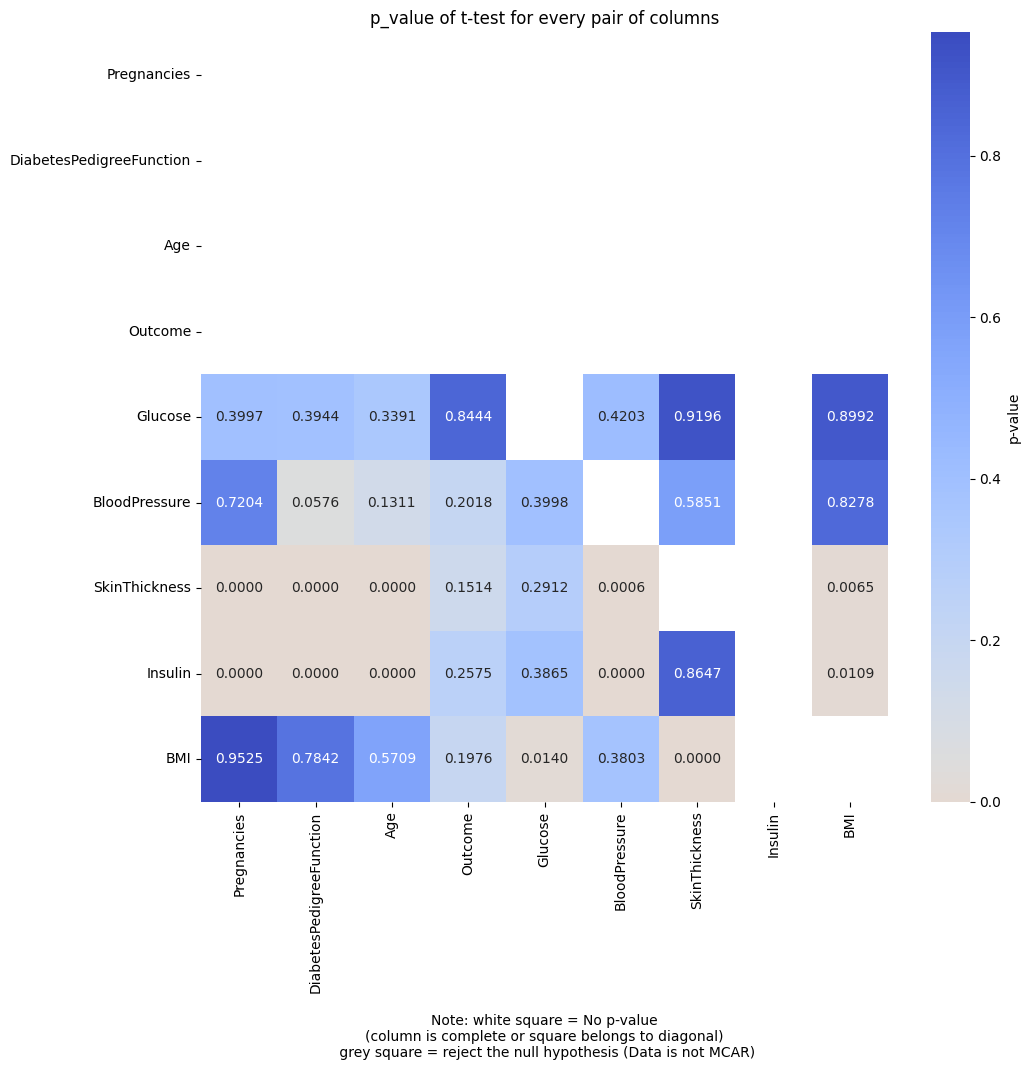

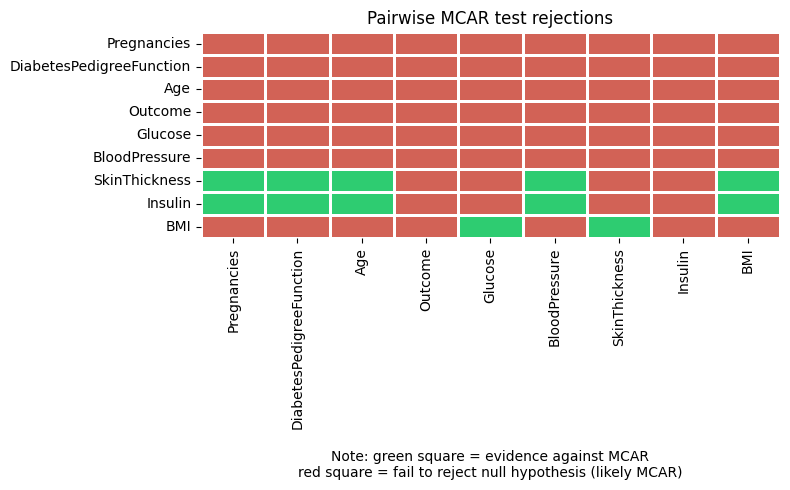

In [12]:
pvalue_matrix = mv.little_mcar_pairwise(df)
_, _, _, _= mv.plot_mcar_pairwise(pvalue_matrix, alpha=0.05, display_plot=True)

The last plot shows that the missingness of `Insulin` and `SkinThickness` is associated with the values of `Pregnancies`, `DiabetesPedigreeFunction`, `Age`, `BloodPressure`, and `BMI`. Furthermore, it is suggested that `BMI` column has its missingness related to the values of `Glucose` and `SkinThickness`.

At this stage, it remains difficult to determine which variables are most influential in driving the missingness, and it is not yet clear whether the missing values tend to occur at lower or higher observed values.

Nevertheless, these results support the earlier interpretation that some variables likely follow a missing‑data mechanism other than MCAR.

In contrast, `BloodPressure` and `Glucose` do not appear to be influenced by any other variable in terms of missingness, suggesting that they are strong candidates for MCAR.

For this dataset, the columns to be inspected further are `Insulin` and `SkinThickness`, due to their increased missing rate, which makes analysis more reliable.


### 6. Row-level missingness patterns

This section looks at whether the rows tend to have the same features missing. This is useful because, despite the high missing rates in `Insulin` and `SkinThickness`, it is not evident that these variables are frequently missing together

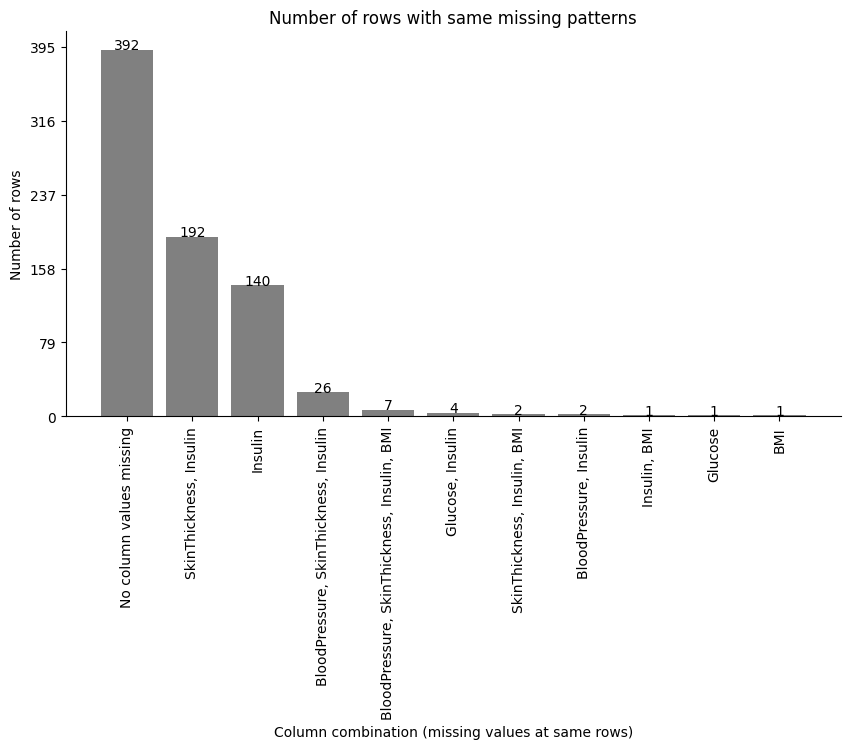

In [13]:
fig_similar_miss, ax_similar_miss = mv.rows_with_similar_missing(df, display_plot=True)

There is a substantial number of rows in which `Insulin` and `SkinThickness` are missing simultaneously. Rows with only `Insulin` missing also occur in meaningful quantity, but they are fewer than the co‑missing cases. This is consistent with `Insulin` having a higher overall missing rate than `SkinThickness`.

A high level of co‑missingness between `Insulin` and `SkinThickness` suggests that the missingness is not noise in specific columns. Instead, it reflects a shared underlying process that affects both variables.

### 7. Visual dependency checks for `Insulin` and `SkinThickness`

The function `build_distribution_of_missingness()` compares the distribution of observed variables for rows where a target column is missing versus observed.

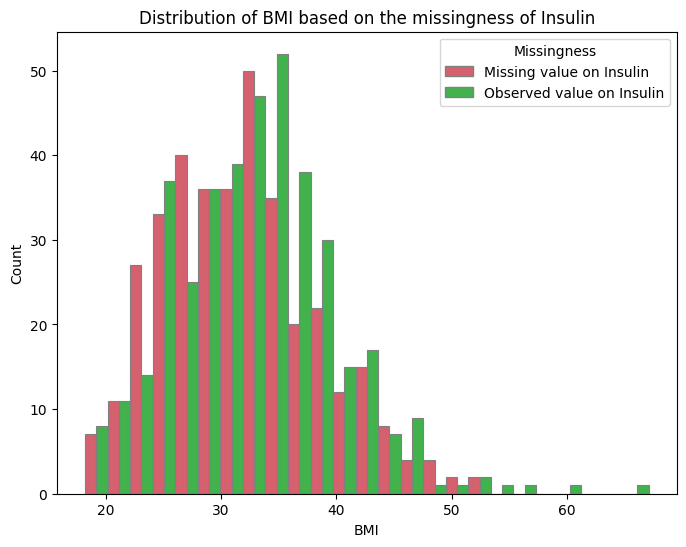

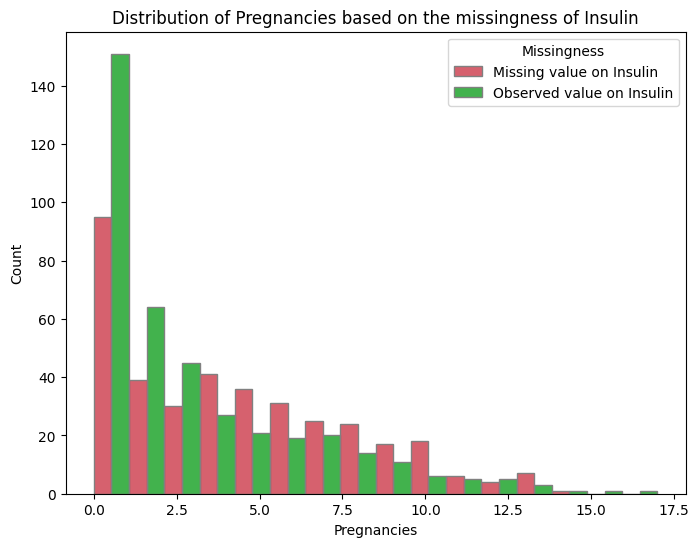

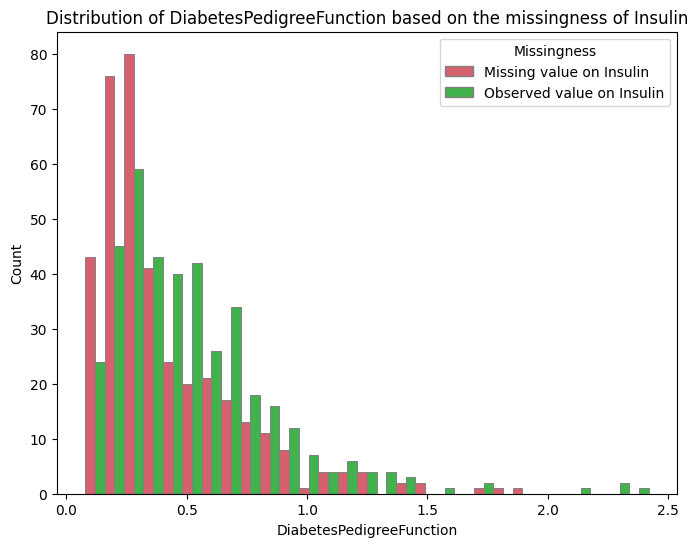

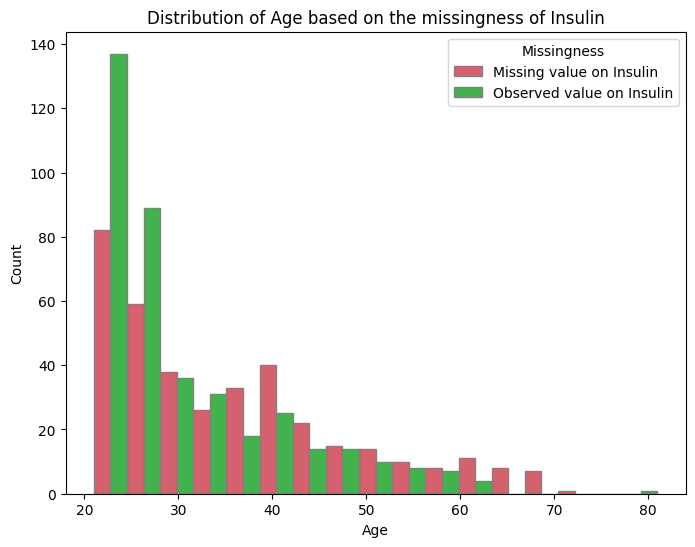

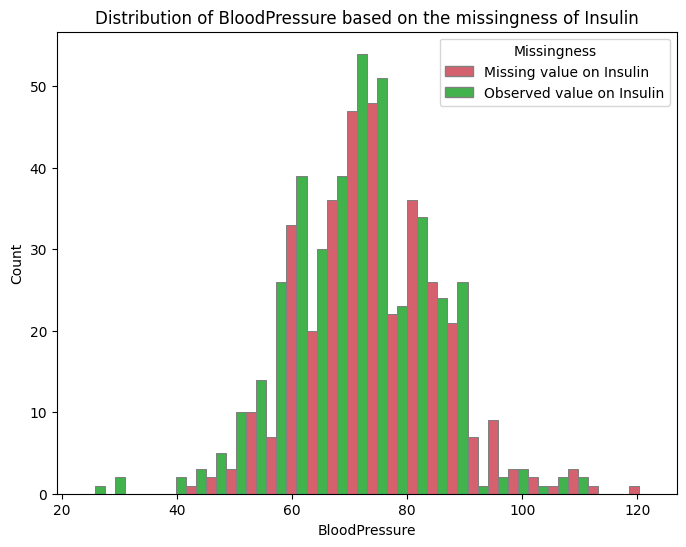

In [31]:
relevant_insulin_columns = ["Insulin", "BMI", "Pregnancies", "DiabetesPedigreeFunction", "Age", "BloodPressure"]

_ = mv.build_distribution_of_missingness(df[relevant_insulin_columns], missing_col="Insulin", display_plot=True)

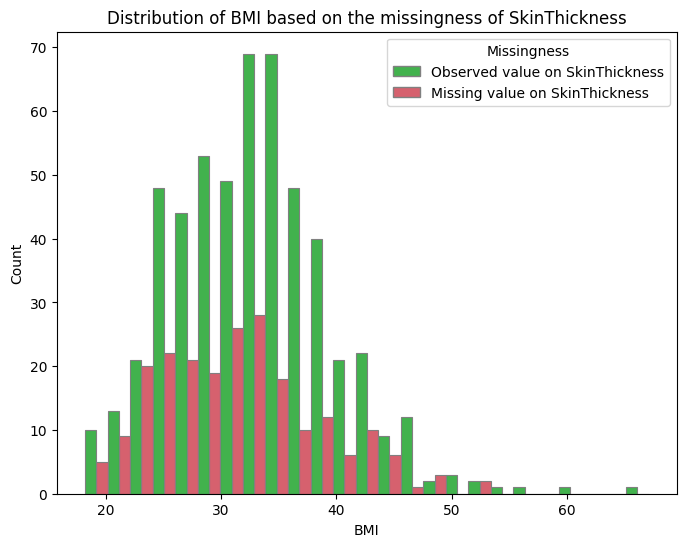

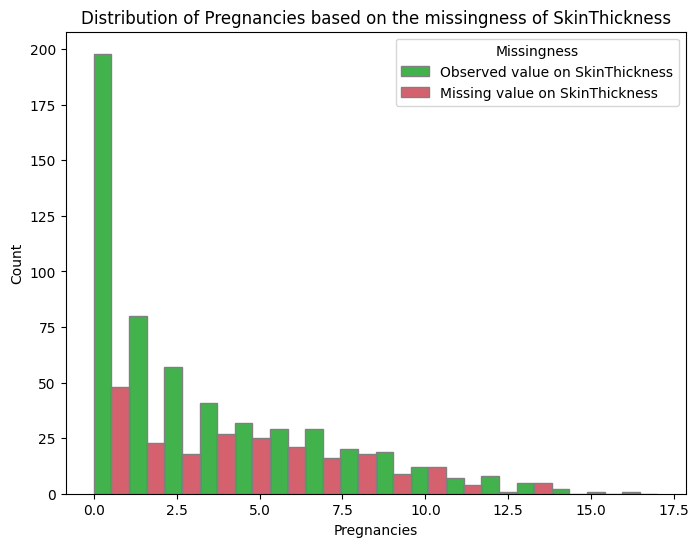

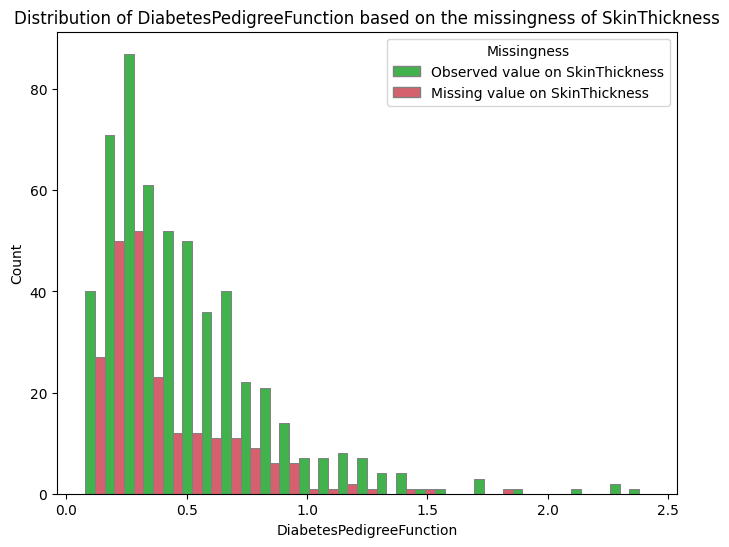

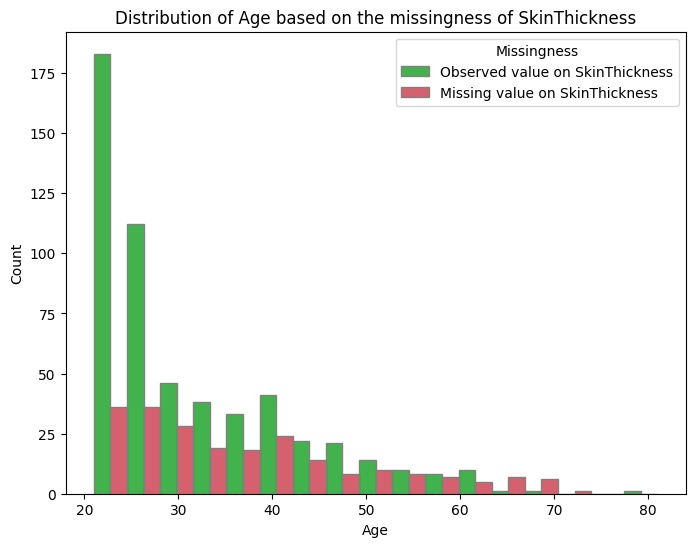

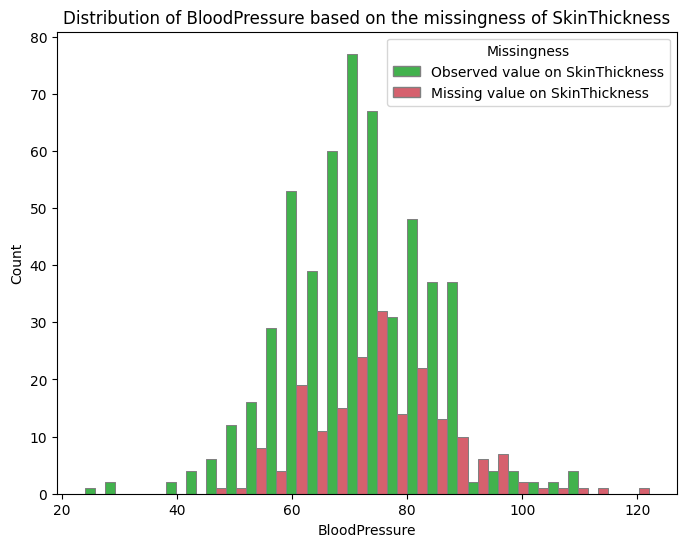

In [32]:
relevant_skin_columns = ["SkinThickness", "BMI", "Pregnancies", "DiabetesPedigreeFunction", "Age", "BloodPressure"]

_ = mv.build_distribution_of_missingness(df[relevant_skin_columns], missing_col="SkinThickness", display_plot=True)

The distribution plots shows overlap rather than a perfectly separated pattern. This means the missingness of `Insulin` and `SkinThickness` is not explained by one simple variable alone.

However, the overlap does not rule out MAR. In real datasets, missingness can depend weakly on several observed variables at the same time.

### 8. Dependency matrix for selected variables

The dependency matrix is useful for checking whether rows with missing `Insulin` or `SkinThickness` concentrate around specific values of complete features: `Age`, `Pregnancies`, or `DiabetesPedigreeFunction`.

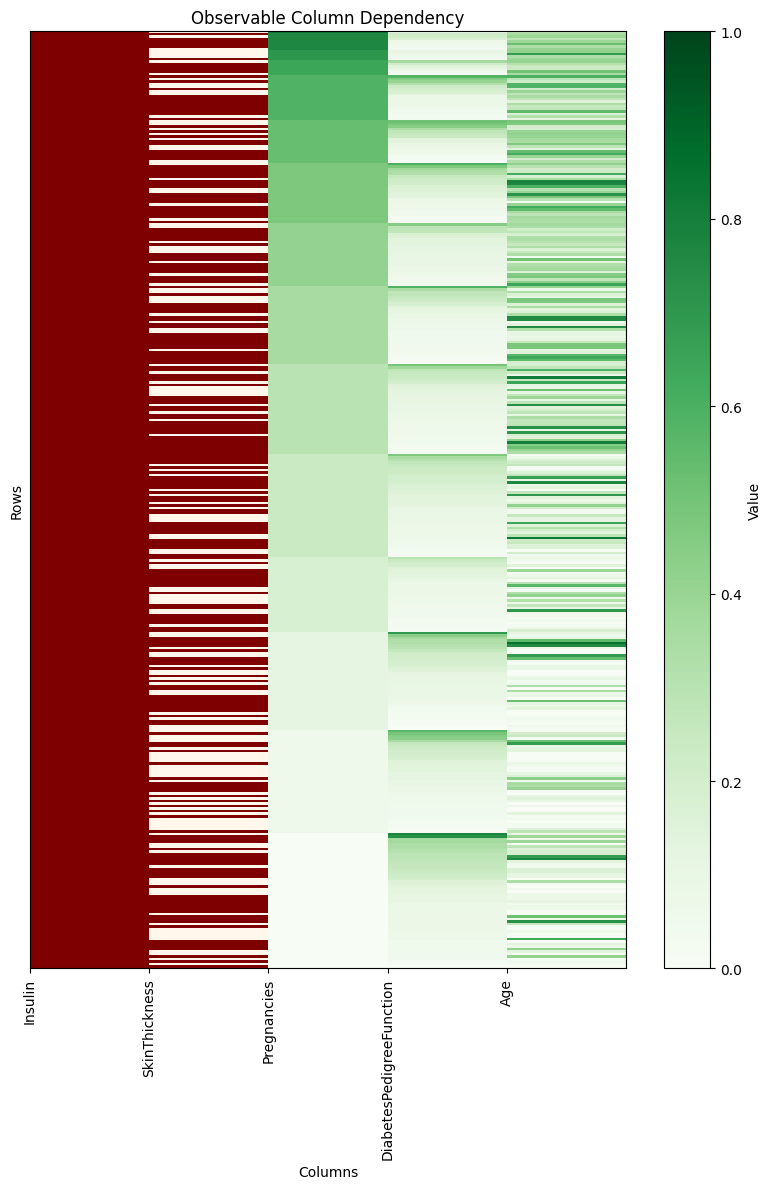

In [35]:
insulin_matrix_cols = ["Insulin", "SkinThickness", "Pregnancies", "DiabetesPedigreeFunction", "Age"]

fig_dep_insulin, ax_dep_insulin = mv.visualize_column_dependencies(
    df[insulin_matrix_cols],
    sort_by_complete=True,
    display_plot=True,
)

Insight into the missingness pattern is available: `Pregnancies`, `DiabetesPedigreeFunction`, and `Age` tend to have lower values.

Although a few high values in these complete variables do appear, they are relatively rare. The most plausible interpretation is that a small portion of the missing values may be MCAR (similar to what is observed for `BloodPressure` and `Glucose`), while most missing values are likely generated under a MAR mechanism dependent on the lower values of `Pregnancies`, `DiabetesPedigreeFunction`, and `Age`.

In the full dataset, the number of rows with high values of `Pregnancies` or `DiabetesPedigreeFunction` is relatively small. This naturally influences the earlier interpretation, since the scarcity of high‑value observations limits how much can be inferred about their relationship to missingness. Therefore, the underlying distribution of these variables should be taken into account when making the final conclusion.

### 9. Missing-rate matrices

The next section uses missing-rate matrices to show how the missing rates of `Insulin` and `SkinThickness` change across the observed values of each individual column.

However, binning is essential for these plots, because each exact value may have too few rows, which makes getting insights on missingness less reliable. Thus, the bins below were chosen to keep the results interpretable while avoiding too many small groups.

In [47]:
df_binned = df.copy()

# Pregnancies
df_binned["Pregnancies_binned"] = pd.cut(df_binned["Pregnancies"], bins=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, np.inf],
                                        labels=["0", "1", "2", "3", "4", "5", "6+"], include_lowest=True)

# Diabetes pedigree function
df_binned["Pedigree_binned"] = pd.qcut(df_binned["DiabetesPedigreeFunction"], q=6, duplicates="drop")

# Age
df_binned["Age_binned"] = pd.cut(df_binned["Age"], bins=[20, 30, 40, 50, 60, np.inf],
                                labels=["20-29", "30-39", "40-49", "50-59", "60+"],
                                right=False, include_lowest=True)

# Blood pressure
df_binned["BloodPressure_binned"] = pd.cut(df_binned["BloodPressure"], bins=[0, 60, 70, 80, 90, np.inf],
                                            labels=["<60", "60-69", "70-79", "80-89", "90+"],
                                            right=False, include_lowest=True)
df_binned["BloodPressure_binned"] = (df_binned["BloodPressure_binned"].cat.add_categories("Missing BP").fillna("Missing BP"))

# BMI
df_binned["BMI_binned"] = pd.cut(df_binned["BMI"], bins=[0, 25, 30, 35, 40, np.inf],
                                labels=["<25", "25-29.9", "30-34.9", "35-39.9", "40+"],
                                right=False, include_lowest=True)
df_binned["BMI_binned"] = (df_binned["BMI_binned"].cat.add_categories("Missing BMI").fillna("Missing BMI"))


bin_cols = ["Age_binned","Pregnancies_binned","Pedigree_binned","BloodPressure_binned", "BMI_binned"]

These plots show whether the missing rate of `Insulin` and `SkinThickness` changes across binned observed variables.

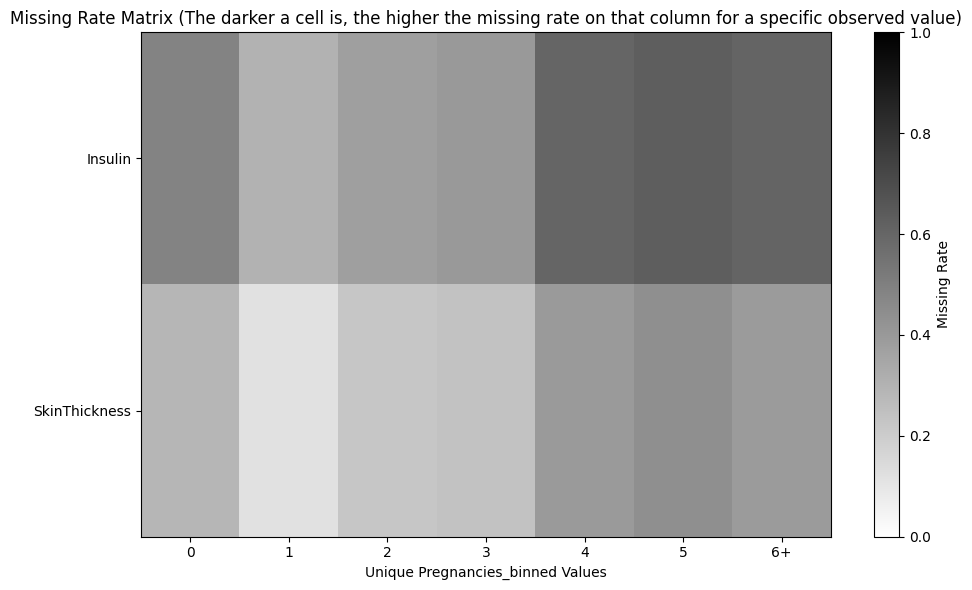

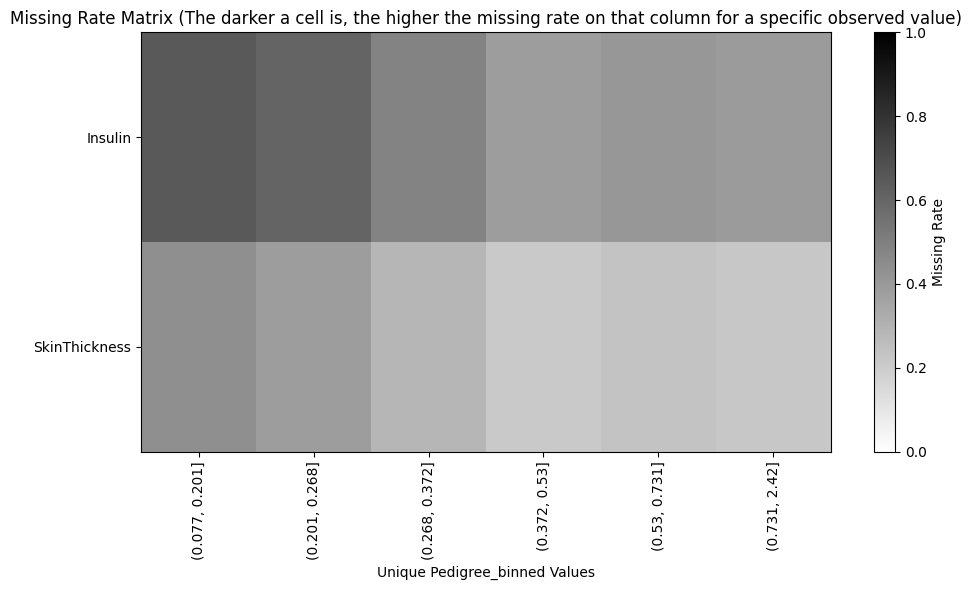

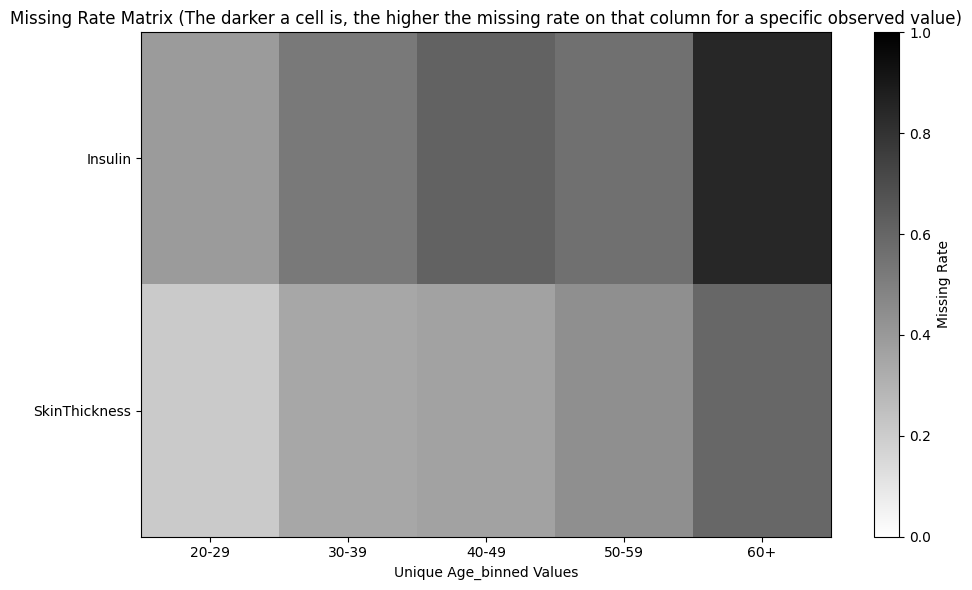

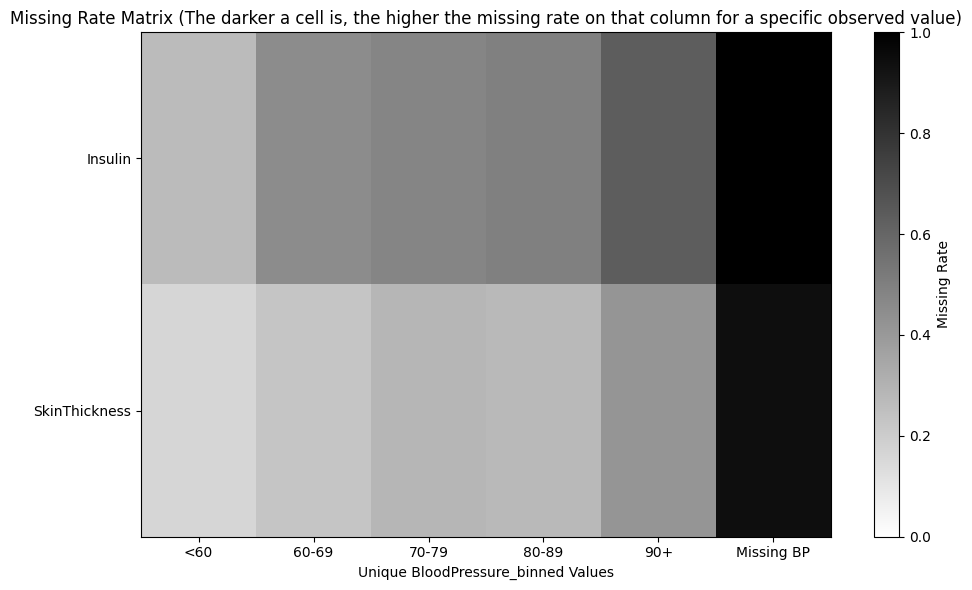

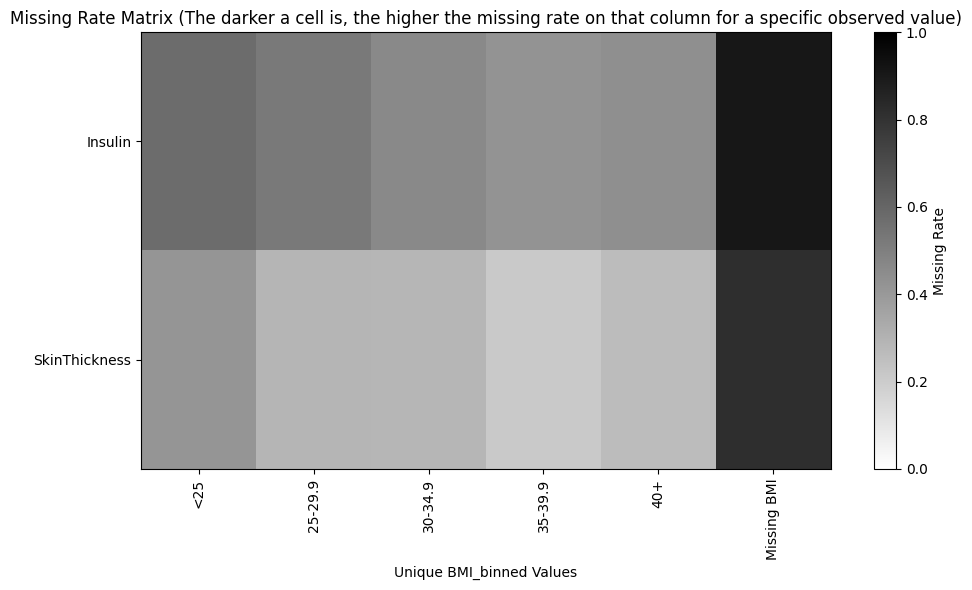

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'Missing Rate Matrix (The darker a cell is, the higher the missing rate on that column for a specific observed value)'}, xlabel='Unique BMI_binned Values'>)

In [48]:
# Pregnancies
mv.missing_rate_matrix(df_binned[["Insulin", "SkinThickness", "Pregnancies_binned"]], column_name="Pregnancies_binned",
                        sort_by_column=True, display_plot=True)

# Diabetes pedigree function
mv.missing_rate_matrix(df_binned[["Insulin", "SkinThickness", "Pedigree_binned"]], column_name="Pedigree_binned",
                       sort_by_column=True, display_plot=True)

# Age
mv.missing_rate_matrix(df_binned[["Insulin", "SkinThickness", "Age_binned"]], column_name="Age_binned",
                        sort_by_column=True, display_plot=True)

# Blood pressure
mv.missing_rate_matrix(df_binned[["Insulin", "SkinThickness", "BloodPressure_binned"]], column_name="BloodPressure_binned",
                        sort_by_column=True, display_plot=True)

# BMI
mv.missing_rate_matrix(df_binned[["Insulin", "SkinThickness", "BMI_binned"]], column_name="BMI_binned",
                        sort_by_column=True, display_plot=True)

By examining the previous plots alongside earlier insights, several useful patterns emerge:

- `Insulin` consistently exhibits a higher missing rate than `SkinThickness`.
- `Insulin` and `SkinThickness` tend to move in the same direction across groups.
- Missingness increases for women with zero `Pregnancies` and for those with more than four `Pregnancies`, although the increase is modest, especially for `SkinThickness`.
- Lower values of `DiabetesPedigreeFunction` are associated with higher missingness.
- As `Age` increases, the missing rates of both `Insulin` and `SkinThickness` rise. However, `Insulin` shows a noticeably higher missing rate in the 60+ age group compared to `SkinThickness`.
- When `BloodPressure` or `BMI` have missing values, it is very likely that `Insulin` and `SkinThickness` are missing as well.
- Higher `BloodPressure` values correspond to increased missingness.
- Lower‑value `BMI` groups show slightly higher missing rates for both `Insulin` and `SkinThickness`.

### 10. Extra: combined groups

Naturally, a single variable comparison can give useful hints. Nevertheless, it is important to see how different variables combined can explain the missingness.

The next tables test whether combinations of variables show clearer patterns. And to avoid unstable conclusions, groups with fewer than `20` rows are filtered out.

In [70]:
def grouped_missing_summary(data, bin_cols):
    summary = data.groupby(bin_cols, observed=True, dropna=False).agg(
        total_count=("Insulin", "size"),
        insulin_missing_rate=("Insulin", lambda x: x.isna().mean()),
        skin_missing_rate=("SkinThickness", lambda x: x.isna().mean()),
    ).reset_index()

    reliable = summary[summary["total_count"] >= 20].copy()
    reliable = reliable.sort_values("insulin_missing_rate", ascending=False)

    return reliable

#### Age and Pregnancies

In [71]:
reliable_age_preg = grouped_missing_summary(df_binned, ["Age_binned", "Pregnancies_binned"])

display(reliable_age_preg.head(15))

,Age_binned,Pregnancies_binned,total_count,insulin_missing_rate,skin_missing_rate
12,30-39,5,21,0.666667,0.380952
11,30-39,4,27,0.629630,0.370370
13,30-39,6+,65,0.600000,0.461538
20,40-49,6+,84,0.583333,0.285714
27,50-59,6+,38,0.578947,0.473684
4,20-29,4,32,0.531250,0.375000
0,20-29,0,87,0.425287,0.229885
3,20-29,3,51,0.392157,0.235294
2,20-29,2,88,0.352273,0.193182
1,20-29,1,104,0.278846,0.086538


It appears that `Pregnancies` carries the missingness dependency more strongly than `Age`, although medium to high `Age` values still have an observable impact on missingness.

#### Age and Pedigree

In [72]:
reliable_age_pedigree = grouped_missing_summary(df_binned, ["Age_binned", "Pedigree_binned"])

display(reliable_age_pedigree.head(15))

,Age_binned,Pedigree_binned,total_count,insulin_missing_rate,skin_missing_rate
12,40-49,"(0.077, 0.201]",23,0.782609,0.565217
7,30-39,"(0.201, 0.268]",26,0.730769,0.500000
6,30-39,"(0.077, 0.201]",20,0.650000,0.550000
13,40-49,"(0.201, 0.268]",24,0.583333,0.333333
0,20-29,"(0.077, 0.201]",70,0.571429,0.314286
10,30-39,"(0.53, 0.731]",23,0.565217,0.391304
1,20-29,"(0.201, 0.268]",63,0.492063,0.269841
8,30-39,"(0.268, 0.372]",31,0.483871,0.225806
9,30-39,"(0.372, 0.53]",24,0.416667,0.250000
11,30-39,"(0.731, 2.42]",41,0.414634,0.268293


`Pedigree` does not appear to combine well with `Age` in revealing a clear missingness pattern.

#### Age and BP

In [74]:
reliable_age_blood = grouped_missing_summary(df_binned, ["Age_binned", "BloodPressure_binned"])

display(reliable_age_blood.head(15))

,Age_binned,BloodPressure_binned,total_count,insulin_missing_rate,skin_missing_rate
5,20-29,Missing BP,20,1.000000,0.950000
9,30-39,80-89,29,0.620690,0.344828
14,40-49,70-79,42,0.619048,0.357143
7,30-39,60-69,35,0.600000,0.371429
13,40-49,60-69,25,0.560000,0.360000
15,40-49,80-89,27,0.518519,0.259259
19,50-59,70-79,26,0.500000,0.384615
8,30-39,70-79,66,0.439394,0.287879
2,20-29,70-79,100,0.400000,0.200000
1,20-29,60-69,130,0.384615,0.146154


Among rows with observed `BloodPressure`, missingness is higher in the 30–49 age range than in 20–29. Since `BloodPressure` shows no clear trend, the pattern is driven more by `Age` and by cases where `BloodPressure` is also missing.

#### Age and BMI

In [75]:
reliable_age_bmi = grouped_missing_summary(df_binned, ["Age_binned", "BMI_binned"])

display(reliable_age_bmi.head(15))

,Age_binned,BMI_binned,total_count,insulin_missing_rate,skin_missing_rate
7,30-39,25-29.9,41,0.634146,0.365854
14,40-49,30-34.9,46,0.630435,0.434783
8,30-39,30-34.9,56,0.535714,0.392857
15,40-49,35-39.9,30,0.500000,0.233333
0,20-29,<25,67,0.492537,0.313433
9,30-39,35-39.9,29,0.448276,0.241379
1,20-29,25-29.9,96,0.406250,0.187500
4,20-29,40+,55,0.381818,0.218182
10,30-39,40+,21,0.380952,0.190476
2,20-29,30-34.9,101,0.336634,0.168317


`Age` and `BMI` do not seem to provide additional insight when considered together.

#### Pregnancies and Pedigree

In [73]:
reliable_preg_pedigree = grouped_missing_summary(df_binned, ["Pregnancies_binned", "Pedigree_binned"])

display(reliable_preg_pedigree.head(15))

,Pregnancies_binned,Pedigree_binned,total_count,insulin_missing_rate,skin_missing_rate
36,6+,"(0.077, 0.201]",43,0.767442,0.604651
38,6+,"(0.268, 0.372]",26,0.730769,0.461538
37,6+,"(0.201, 0.268]",37,0.702703,0.459459
1,0,"(0.201, 0.268]",22,0.681818,0.363636
39,6+,"(0.372, 0.53]",32,0.562500,0.375000
6,1,"(0.077, 0.201]",20,0.550000,0.200000
5,0,"(0.731, 2.42]",22,0.500000,0.318182
41,6+,"(0.731, 2.42]",40,0.500000,0.250000
12,2,"(0.077, 0.201]",21,0.476190,0.285714
40,6+,"(0.53, 0.731]",41,0.414634,0.219512


No insights can be brought from this combination.

#### Pregnancies and BMI

In [ ]:
reliable_preg_bmi = grouped_missing_summary(df_binned, ["Pregnancies_binned", "BMI_binned"])

display(reliable_preg_bmi.head(15))

,Pregnancies_binned,BMI_binned,total_count,insulin_missing_rate,skin_missing_rate
34,6+,<25,24,0.791667,0.625000
24,4,25-29.9,20,0.650000,0.300000
35,6+,25-29.9,48,0.625000,0.416667
36,6+,30-34.9,70,0.600000,0.385714
25,4,30-34.9,24,0.583333,0.458333
38,6+,40+,23,0.565217,0.260870
2,0,30-34.9,26,0.538462,0.307692
37,6+,35-39.9,50,0.500000,0.280000
12,2,25-29.9,31,0.483871,0.258065
3,0,35-39.9,20,0.400000,0.250000


`Pregnancies` seems to be driving the missingness compared to `BMI`, although a low `BMI` helps to increase the missingness.

#### Pregnancies and BP

In [ ]:
reliable_preg_bp = grouped_missing_summary(df_binned, ["Pregnancies_binned", "BloodPressure_binned"])

display(reliable_preg_bp.head(15))

,Pregnancies_binned,BloodPressure_binned,total_count,insulin_missing_rate,skin_missing_rate
32,5,70-79,26,0.692308,0.384615
38,6+,80-89,50,0.680000,0.400000
36,6+,60-69,41,0.658537,0.390244
39,6+,90+,26,0.653846,0.461538
25,4,60-69,20,0.650000,0.400000
2,0,70-79,21,0.571429,0.380952
26,4,70-79,24,0.541667,0.416667
37,6+,70-79,82,0.500000,0.317073
20,3,70-79,26,0.500000,0.346154
13,2,60-69,31,0.419355,0.161290


The grouped table suggests that missingness is higher among patients with more `Pregnancies`, especially in the 4, 5, and 6+ pregnancy groups. This pattern is visible across several `BloodPressure` bins, which suggests that `Pregnancies` may be a stronger observed predictor of missingness than `BloodPressure` alone.

#### Pedigree and BMI

In [79]:
reliable_ped_bmi = grouped_missing_summary(df_binned, ["Pedigree_binned", "BMI_binned"])

display(reliable_ped_bmi.head(15))

,Pedigree_binned,BMI_binned,total_count,insulin_missing_rate,skin_missing_rate
0,"(0.077, 0.201]",<25,23,0.826087,0.608696
7,"(0.201, 0.268]",25-29.9,33,0.757576,0.484848
3,"(0.077, 0.201]",35-39.9,22,0.636364,0.454545
1,"(0.077, 0.201]",25-29.9,32,0.625000,0.375000
6,"(0.201, 0.268]",<25,26,0.615385,0.423077
2,"(0.077, 0.201]",30-34.9,39,0.589744,0.358974
8,"(0.201, 0.268]",30-34.9,30,0.533333,0.300000
27,"(0.53, 0.731]",40+,20,0.500000,0.400000
14,"(0.268, 0.372]",30-34.9,35,0.485714,0.400000
13,"(0.268, 0.372]",25-29.9,33,0.484848,0.181818


The highest missing rates occur primarily in the lower `DiabetesPedigreeFunction` bins, especially when combined with lower or moderate `BMI` values. However, `BMI` does not show a consistent monotonic relationship with missingness, so the pattern should not be attributed to `BMI` alone. Instead, `DiabetesPedigreeFunction` appears to be the stronger grouping variable, with BMI acting as a secondary modifier.

#### Pedigree and PB

In [80]:
reliable_ped_bp = grouped_missing_summary(df_binned, ["Pedigree_binned", "BloodPressure_binned"])

display(reliable_ped_bp.head(15))

,Pedigree_binned,BloodPressure_binned,total_count,insulin_missing_rate,skin_missing_rate
7,"(0.201, 0.268]",60-69,28,0.714286,0.321429
1,"(0.077, 0.201]",60-69,34,0.676471,0.411765
14,"(0.268, 0.372]",70-79,36,0.583333,0.388889
8,"(0.201, 0.268]",70-79,43,0.581395,0.348837
2,"(0.077, 0.201]",70-79,42,0.523810,0.333333
33,"(0.731, 2.42]",80-89,34,0.500000,0.176471
27,"(0.53, 0.731]",80-89,24,0.500000,0.416667
15,"(0.268, 0.372]",80-89,23,0.478261,0.260870
9,"(0.201, 0.268]",80-89,28,0.464286,0.285714
20,"(0.372, 0.53]",70-79,43,0.441860,0.279070


The highest missing rates mostly occur in the lower `DiabetesPedigreeFunction` bins, especially when `BloodPressure` is around 60–79. The highest pedigree bin generally shows lower missingness, particularly for `SkinThickness`. Since `BloodPressure` does not follow a clear monotonic pattern, the effect is mainly driven by `DiabetesPedigreeFunction`, with `BloodPressure` acting as a secondary factor.

#### Summary

The analysis highlights two main points for the missingness of `Insulin` and `SkinThickness`:

- `DiabetesPedigreeFunction` is a strong indicator of missingness, while `BloodPressure` and `BMI` mainly add secondary detail.

- `Pregnancies` is the most consistent driver of missingness across all variable combinations, with `BMI` and `Age` acting as helpful but weaker contributors.
  
Overall, this shows how each variable contributes to the missingness of `Insulin` and `SkinThickness`, supporting the conclusion that both features follow a MAR mechanism.

### 11. Extra: missingness of `BMI`

As noted earlier, `BMI` has a very small missing rate. The pairwise MCAR test suggested a possible MAR pattern linked to `SkinThickness` and `Glucose`, but the missing rate is too low to draw firm conclusions.

Anyway, the next plot will explore whether `BMI` shows any signs of MAR behavior.

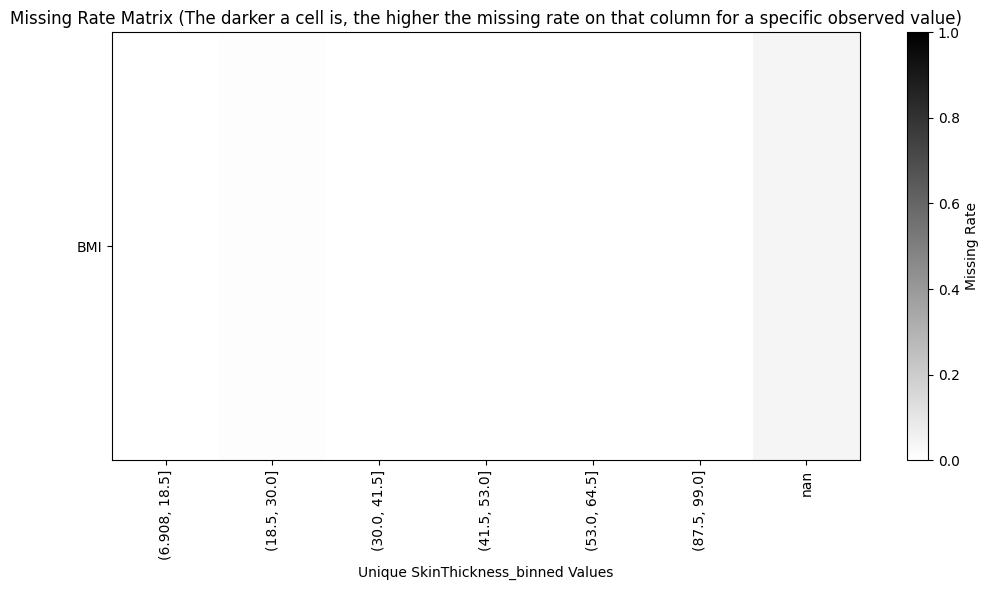

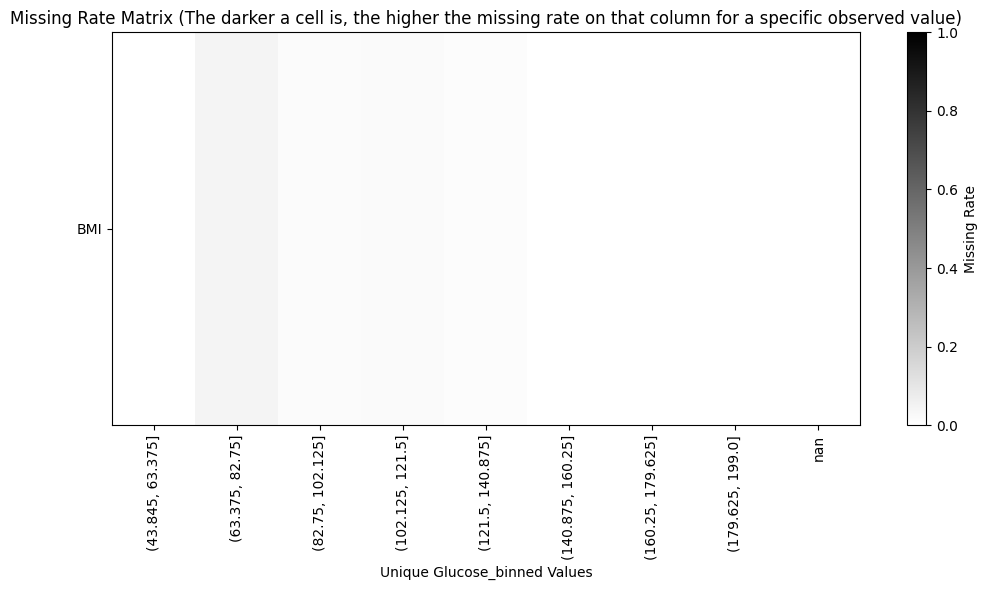

In [85]:
df_binned["SkinThickness_binned"] = pd.cut(df_binned["SkinThickness"], bins=8)
df_binned["Glucose_binned"] = pd.cut(df_binned["Glucose"], bins=8)

_ = mv.missing_rate_matrix(df_binned[["BMI", "SkinThickness_binned"]], column_name="SkinThickness_binned",
                        sort_by_column=True, display_plot=True)

_ = mv.missing_rate_matrix(df_binned[["BMI", "Glucose_binned"]], column_name="Glucose_binned",
                        sort_by_column=True, display_plot=True)

The BMI missingness plots show weak practical structure because there are very few missing BMI values. Therefore, this visual evidence does  not help confirm the non-MCAR behaviour.

Other methods can be used, such as `detect_mar_from_model_accuracy()`.

In [87]:
_ = mv.detect_mar_from_model_accuracy(df, missing_col="BMI", print_result=True)

C:\Users\Utiizador\Desktop\mestrado1\semestre1\IA_E_SOCIEDADE\individual_assignment\mechanism_viewer\mechanism_viewer\accuracy_mar.py:135: UserWarning: Test set may be too small for reliable evaluation!                       Increase the dataset size to produce more reliable results.
  warnings.warn("Test set may be too small for reliable evaluation! \


Random Forest Model Accuracy: 0.9870
Logistic Regression Model Accuracy: 0.9870
The target column BMI with missing rate of 0.014322916666666666 gives an Accuracy Baseline Difference of 0.13.
Since the obtained Accuracy Baseline Difference is 0.13, and the given threshold is 5.0, thus, it is likely that the underlying mechanism of the missing column is MCAR/MNAR.


C:\Users\Utiizador\Desktop\mestrado1\semestre1\IA_E_SOCIEDADE\individual_assignment\mechanism_viewer\mechanism_viewer\accuracy_mar.py:135: UserWarning: Test set may be too small for reliable evaluation!                       Increase the dataset size to produce more reliable results.
  warnings.warn("Test set may be too small for reliable evaluation! \


This approach also shows that the test set may be too small for a reliable evaluation. Because of that, its result can appear MCAR or even MNAR, which goes against the idea of a MAR pattern.

### 12. Final conclusion

Overall, the dataset is unlikely to be purely MCAR, after impossible zero values were converted to `NaN`. In fact, the global MCAR test rejects MCAR, and the visual checks show structured missingness, especially for `Insulin` and `SkinThickness`. These features show strong co-missingness and weaker dependencies on several observed variables. 

The strongest conclusions are as follows:

- `Insulin` has the highest missing rate and is the main source of the missingness problem.  
- `SkinThickness` also has substantial missingness and often goes missing together with `Insulin`.  
- The missingness of both variables varies across observed features such as `Age`, `Pregnancies`, `DiabetesPedigreeFunction`, `BloodPressure`, and `BMI`.  
- These patterns point toward a **MAR component**, since missingness is partly explained by observed variables.  
- However, the evidence is not strong enough to claim a purely MAR mechanism. Real clinical data often reflects a mix of MAR, MCAR, and possibly MNAR.  
- Pairwise comparisons show that some variables strongly relate to missingness, while others mainly reinforce those stronger drivers.  
- `BloodPressure`, `Glucose`, and `BMI` have much lower missing rates. `BloodPressure` and `Glucose` did not reject MCAR, while `BMI` did. Their individual mechanisms should therefore be interpreted with caution.

However, because the visual patterns are not perfectly separated and some subgroup counts are small, the conclusion should be treated as exploratory rather than definitive.